#  Thermal & Electrical Anomalies — Question 2a
**Which temperature features show the strongest signals before fault events?**

### Approach
We compare temperature sensor behaviour in the lead-up to known fault events
across all three farms. We quantify signal strength using:
- Mean shift (normal vs pre-fault)
- Signal-to-noise ratio (mean shift / standard deviation)
- Correlation with fault proximity

### Sections
1. Setup & Data Loading
2. Farm A — Transformer Failure Analysis
3. Farm B — Transformer Cell Overheating Analysis
4. Farm C — Hydraulic & Electrical Fault Analysis
5. Cross-Farm Feature Importance Comparison

---
## Section 1 — Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(' Imports OK')

✅ Imports OK


In [ ]:
#  UPDATE BASE PATH
BASE = Path('/Users/prabhaseessingh/Desktop/Data Science/DSMLCFinalComp/CARE_To_Compare')

FARM_A = BASE / 'Wind Farm A'
FARM_B = BASE / 'Wind Farm B'
FARM_C = BASE / 'Wind Farm C'

def load_farm(farm_path):
    return {
        'event_info': pd.read_csv(farm_path / 'event_info.csv', sep=';'),
        'feat_desc':  pd.read_csv(farm_path / 'feature_description.csv', sep=';'),
        'datasets':   farm_path / 'datasets'
    }

def get_label(feat_desc, bare_name):
    d = feat_desc[feat_desc['sensor_name'] == bare_name]['description'].values
    return d[0] if len(d) > 0 else bare_name

def load_event(farm, event_id):
    df = pd.read_csv(farm['datasets'] / f'{event_id}.csv', sep=';')
    return df.sort_values('id').reset_index(drop=True)

farms = {
    'A': load_farm(FARM_A),
    'B': load_farm(FARM_B),
    'C': load_farm(FARM_C)
}

for name, farm in farms.items():
    ei = farm['event_info']
    print(f'Farm {name}: {len(ei)} events ({(ei["event_label"]=="anomaly").sum()} anomaly, {(ei["event_label"]=="normal").sum()} normal)')

Farm A: 22 events (12 anomaly, 10 normal)
Farm B: 15 events (6 anomaly, 9 normal)
Farm C: 58 events (27 anomaly, 31 normal)


In [ ]:
def compute_signal_strength(df_anomaly, df_normal, sensor_cols, feat_desc, top_n=10):
    """
    For each sensor, compute:
    - Normal mean and std
    - Anomaly mean and std
    - Mean shift (absolute difference)
    - Signal-to-noise ratio: |mean_shift| / normal_std
    Returns top_n sensors ranked by SNR.
    """
    rows = []
    for col in sensor_cols:
        if col not in df_anomaly.columns or col not in df_normal.columns:
            continue
        n_mean = df_normal[col].mean()
        n_std  = df_normal[col].std()
        a_mean = df_anomaly[col].mean()
        shift  = abs(a_mean - n_mean)
        snr    = shift / (n_std + 1e-9)
        bare   = col.replace('_avg', '')
        label  = get_label(feat_desc, bare)
        rows.append({
            'sensor': col,
            'description': label,
            'normal_mean': round(n_mean, 2),
            'anomaly_mean': round(a_mean, 2),
            'mean_shift': round(shift, 2),
            'snr': round(snr, 3)
        })
    result = pd.DataFrame(rows).sort_values('snr', ascending=False)
    return result.head(top_n)

print(' Helper functions ready')

✅ Helper functions ready


---
## Section 2 — Farm A: Transformer Failure Analysis
Farm A has 1 transformer failure event (event 68).
We compare transformer phase temperatures against a normal event.

In [4]:
farm_a    = farms['A']
feat_a    = farm_a['feat_desc']

# Load transformer failure event and a normal event
df_a_fault  = load_event(farm_a, 68)   # Transformer failure
df_a_normal = load_event(farm_a, 25)   # Normal event

train_end_a = df_a_fault[df_a_fault['train_test'] == 'train'].index.max()

# Farm A thermal sensors — transformer and generator
THERMAL_A = [
    'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg',  # HV transformer L1/L2/L3
    'sensor_15_avg', 'sensor_16_avg', 'sensor_17_avg',  # Generator stator windings
    'sensor_13_avg', 'sensor_14_avg',                   # Generator bearings
    'sensor_11_avg', 'sensor_12_avg',                   # Gearbox bearing + oil
    'sensor_0_avg',                                     # Ambient
]

signal_a = compute_signal_strength(df_a_fault, df_a_normal, THERMAL_A, feat_a)
print('Farm A — Top thermal signals before transformer failure:')
signal_a

Farm A — Top thermal signals before transformer failure:


,sensor,description,normal_mean,anomaly_mean,mean_shift,snr
0,sensor_38_avg,Temperature in HV transformer phase L1,68.38,68.97,0.59,0.062
10,sensor_0_avg,Ambient temperature,20.11,20.43,0.31,0.058
1,sensor_39_avg,Temperature in HV transformer phase L2,77.25,76.99,0.27,0.021
2,sensor_40_avg,Temperature in HV transformer phase L3,76.38,76.63,0.25,0.014
9,sensor_12_avg,Temperature oil in gearbox,47.43,47.51,0.09,0.013
7,sensor_14_avg,Temperature in generator bearing 1 (Non-Drive ...,46.37,46.18,0.20,0.012
6,sensor_13_avg,Temperature in generator bearing 2 (Drive End),44.82,44.98,0.16,0.011
8,sensor_11_avg,Temperature in gearbox bearing on high speed s...,50.95,51.04,0.10,0.010
3,sensor_15_avg,Temperature inside generator in stator winding...,68.13,68.36,0.23,0.007
4,sensor_16_avg,Temperature inside generator in stator winding...,66.74,66.95,0.21,0.007


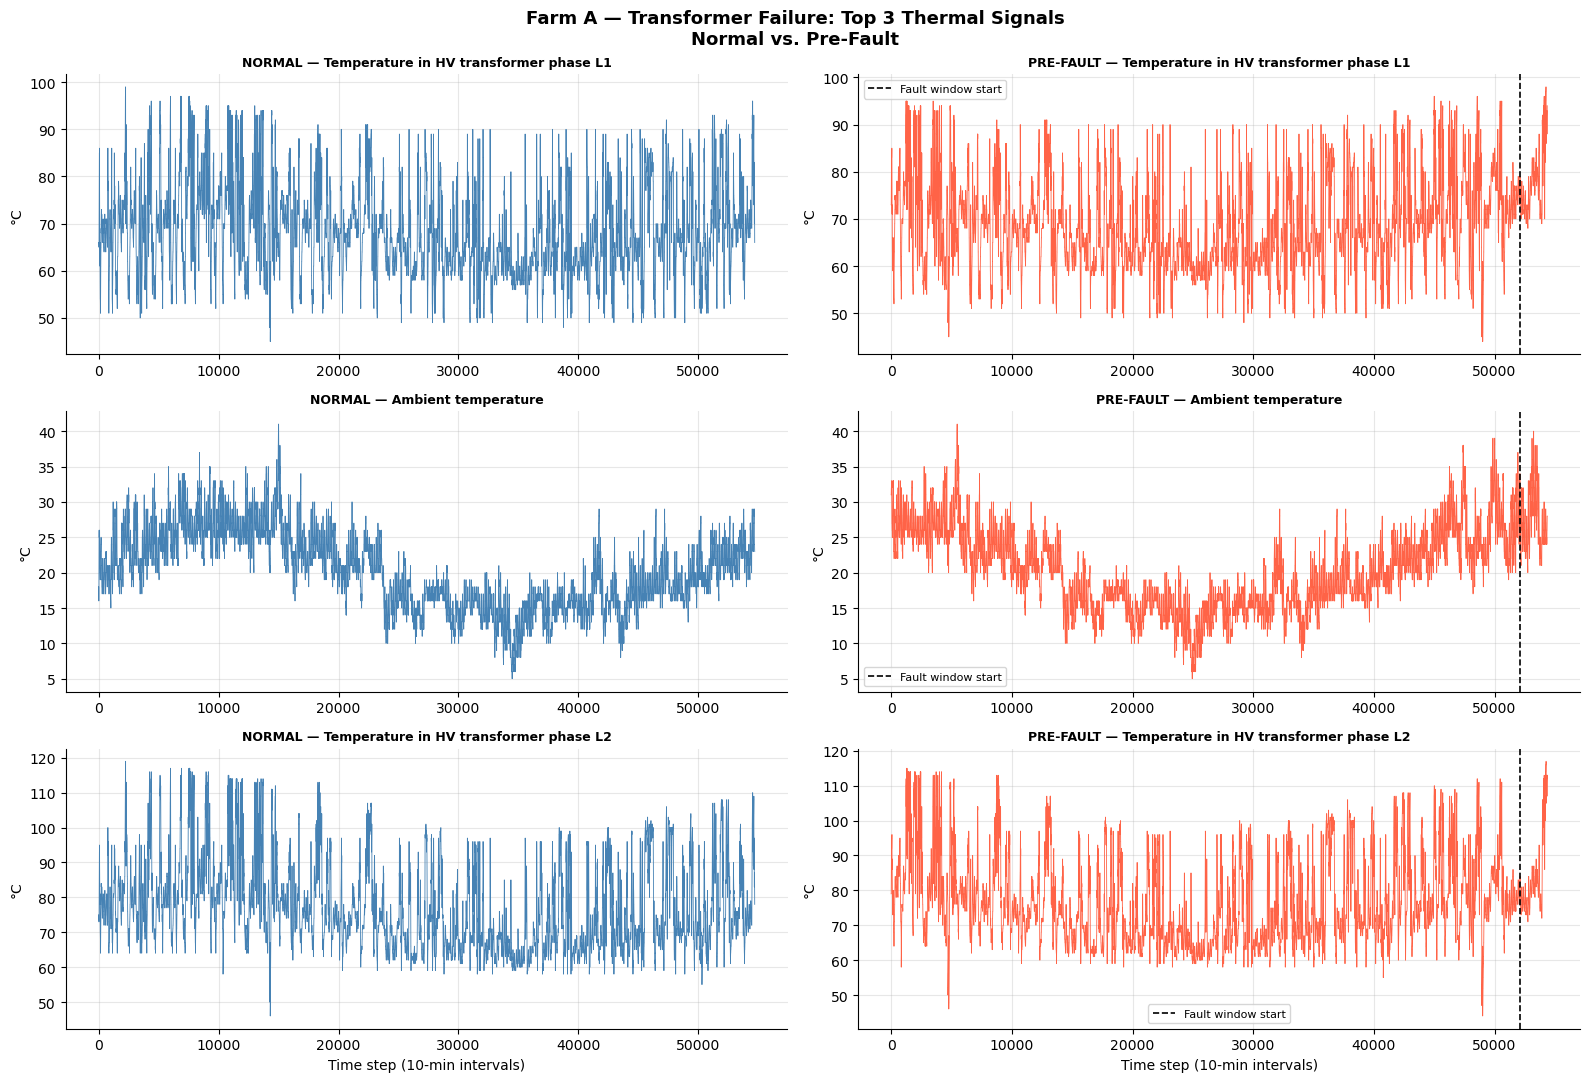

💾 Saved: farm_a_thermal_signals.png


In [ ]:
# Plot top 3 sensors from Farm A
top3_a = signal_a['sensor'].tolist()[:3]

fig, axes = plt.subplots(3, 2, figsize=(16, 11))
fig.suptitle('Farm A — Transformer Failure: Top 3 Thermal Signals\nNormal vs. Pre-Fault',
             fontsize=13, fontweight='bold')

for i, col in enumerate(top3_a):
    bare  = col.replace('_avg', '')
    label = get_label(feat_a, bare)

    ax_n = axes[i][0]
    ax_n.plot(df_a_normal.index, df_a_normal[col], color='steelblue', linewidth=0.6)
    ax_n.set_title(f'NORMAL — {label}', fontsize=9, fontweight='bold')
    ax_n.set_ylabel('°C')

    ax_a = axes[i][1]
    ax_a.plot(df_a_fault.index, df_a_fault[col], color='tomato', linewidth=0.6)
    ax_a.axvline(x=train_end_a, color='black', linestyle='--', linewidth=1.2,
                 label='Fault window start')
    ax_a.set_title(f'PRE-FAULT — {label}', fontsize=9, fontweight='bold')
    ax_a.set_ylabel('°C')
    ax_a.legend(fontsize=8)

axes[-1][0].set_xlabel('Time step (10-min intervals)')
axes[-1][1].set_xlabel('Time step (10-min intervals)')
plt.tight_layout()
plt.savefig('farm_a_thermal_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_a_thermal_signals.png')

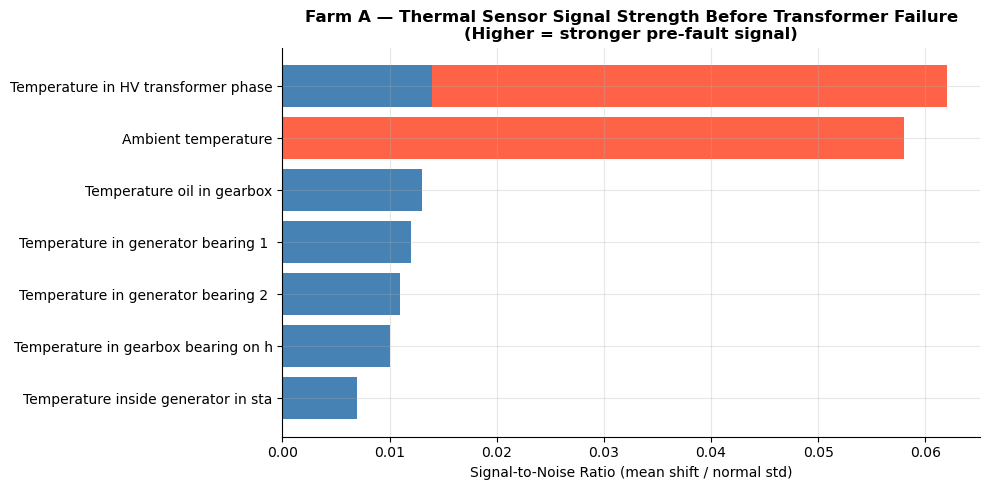

💾 Saved: farm_a_snr.png


In [ ]:
# SNR bar chart — Farm A
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['tomato' if i < 3 else 'steelblue' for i in range(len(signal_a))]
ax.barh(signal_a['description'].str[:35], signal_a['snr'], color=colors)
ax.set_xlabel('Signal-to-Noise Ratio (mean shift / normal std)')
ax.set_title('Farm A — Thermal Sensor Signal Strength Before Transformer Failure\n'
             '(Higher = stronger pre-fault signal)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('farm_a_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_a_snr.png')

---
## Section 3 — Farm B: Transformer Cell Overheating Analysis
Farm B has 3 transformer cell overheating events.
Key sensors: sensor_47 (transformer cell temp), sensor_40/41/42/43/44/45/46 (transformer phases).

In [7]:
farm_b = farms['B']
feat_b = farm_b['feat_desc']
ei_b   = farm_b['event_info']

# Get transformer overheating events
transformer_b = ei_b[
    ei_b['event_description'].str.contains('transformer', case=False, na=False)
]
print('Farm B transformer events:')
print(transformer_b[['event_id', 'event_description', 'event_start', 'event_end']])

# Load first transformer event and a normal event
normal_b   = ei_b[ei_b['event_label'] == 'normal']
df_b_fault  = load_event(farm_b, transformer_b['event_id'].iloc[0])
df_b_normal = load_event(farm_b, normal_b['event_id'].iloc[0])
train_end_b = df_b_fault[df_b_fault['train_test'] == 'train'].index.max()

print(f'\nFault event shape: {df_b_fault.shape}')
print(f'Normal event shape: {df_b_normal.shape}')
print(f'Train/predict split at index: {train_end_b}')

Farm B transformer events:
   event_id                     event_description          event_start  \
0        34  high temperature in transformer cell  2023-08-24 00:00:00   
1         7  high temperature in transformer cell  2023-07-01 00:00:00   
4        19  high temperature in transformer cell  2023-02-03 00:00:00   

             event_end  
0  2023-09-15 00:00:00  
1  2023-08-01 00:00:00  
4  2023-02-23 00:00:00  

Fault event shape: (56564, 257)
Normal event shape: (66154, 257)
Train/predict split at index: 52530


In [8]:
# Farm B thermal sensors
THERMAL_B = [
    'sensor_47_avg',  # Transformer cell temperature — primary target
    'sensor_40_avg',  # Transformator core temperature
    'sensor_41_avg',  # Transformer L1 mid-voltage
    'sensor_42_avg',  # Transformer L1 undervoltage
    'sensor_43_avg',  # Transformer L2 mid-voltage
    'sensor_44_avg',  # Transformer L2 undervoltage
    'sensor_45_avg',  # Transformer L3 mid-voltage
    'sensor_46_avg',  # Transformer L3 undervoltage
    'sensor_32_avg',  # Generator bearing 1
    'sensor_33_avg',  # Generator bearing 2
    'sensor_8_avg',   # Outside temperature
]

signal_b = compute_signal_strength(df_b_fault, df_b_normal, THERMAL_B, feat_b)
print('Farm B — Top thermal signals before transformer cell overheating:')
signal_b

Farm B — Top thermal signals before transformer cell overheating:


,sensor,description,normal_mean,anomaly_mean,mean_shift,snr
0,sensor_47_avg,Transformer cell temperature,75.08,53.80,21.28,0.849
1,sensor_40_avg,Transformator core temperature,113.25,107.43,5.82,0.482
9,sensor_33_avg,Generator bearing temperature 2,49.32,44.39,4.92,0.453
6,sensor_45_avg,Transformer L3 (mid-voltage) temperature,58.98,51.66,7.31,0.435
7,sensor_46_avg,Transformer L3 (undervoltage) temperature,66.52,62.72,3.80,0.278
8,sensor_32_avg,Generator bearing temperature 1,51.30,49.22,2.08,0.160
5,sensor_44_avg,Transformer L2 (undervoltage) temperature,70.41,71.55,1.13,0.099
2,sensor_41_avg,Transformer L1 (mid-voltage) temperature,51.65,52.31,0.67,0.042
4,sensor_43_avg,Transformer L2 (mid-voltage) temperature,54.02,53.35,0.67,0.041
10,sensor_8_avg,Outside temperature,13.06,12.92,0.14,0.024


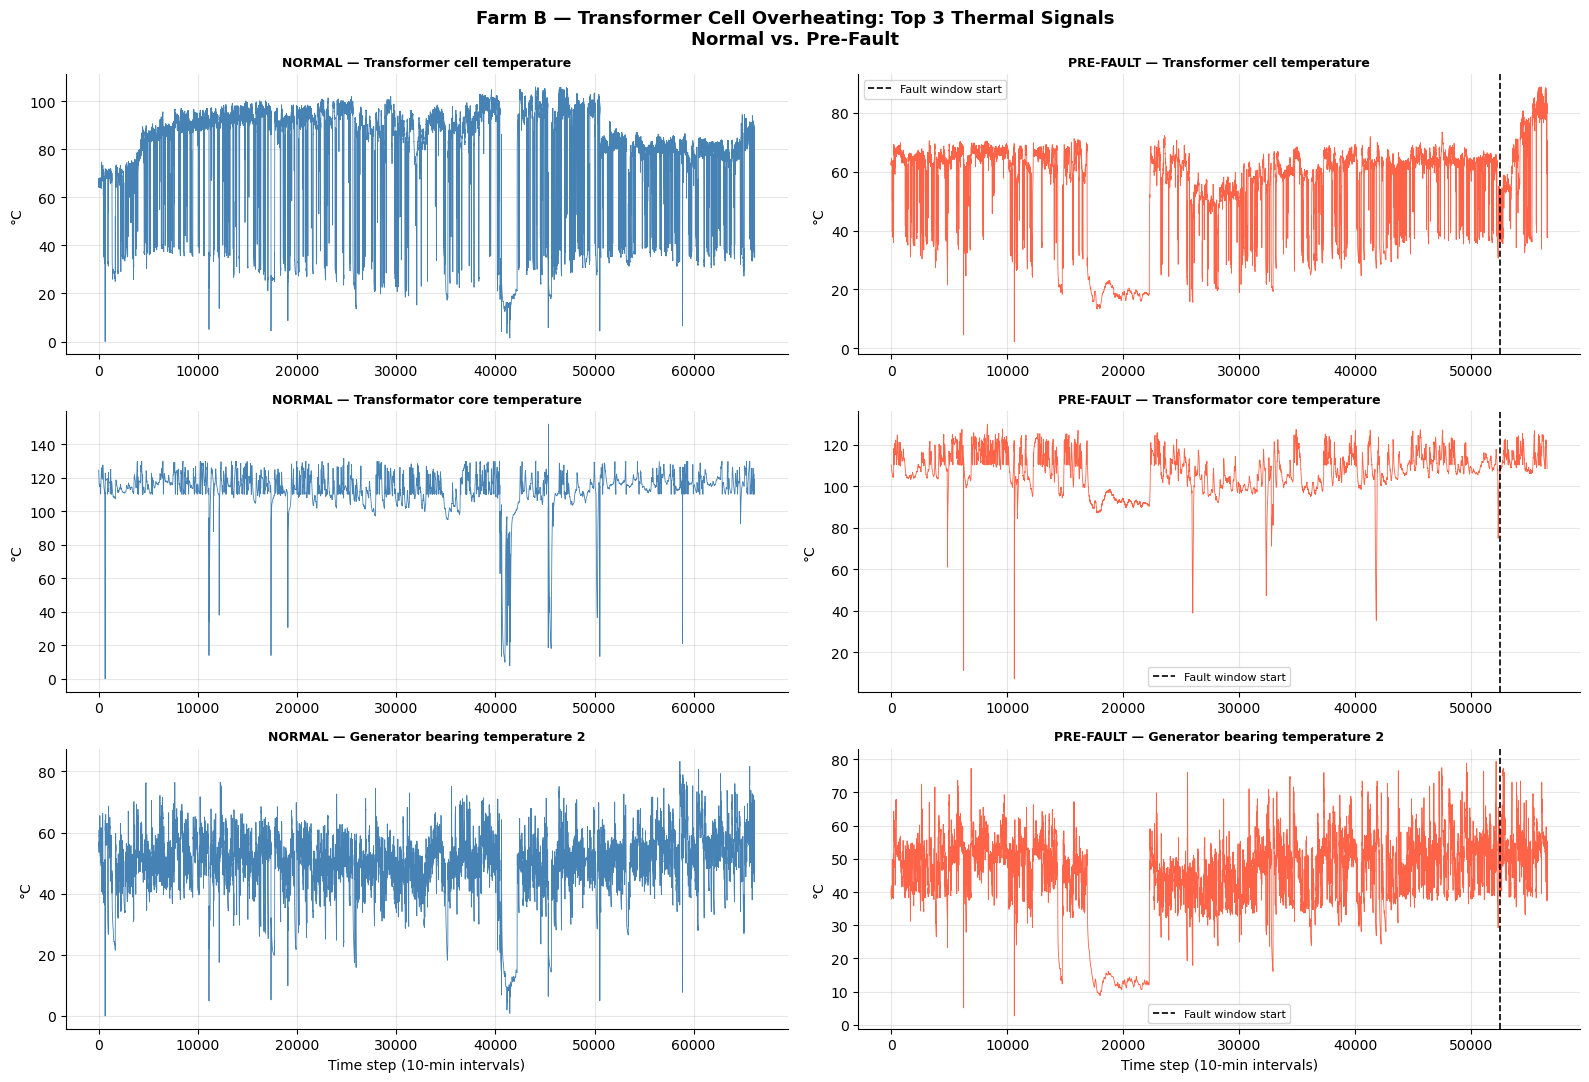

💾 Saved: farm_b_thermal_signals.png


In [ ]:
# Plot top 3 Farm B sensors
top3_b = signal_b['sensor'].tolist()[:3]

fig, axes = plt.subplots(3, 2, figsize=(16, 11))
fig.suptitle('Farm B — Transformer Cell Overheating: Top 3 Thermal Signals\nNormal vs. Pre-Fault',
             fontsize=13, fontweight='bold')

for i, col in enumerate(top3_b):
    bare  = col.replace('_avg', '')
    label = get_label(feat_b, bare)

    ax_n = axes[i][0]
    if col in df_b_normal.columns:
        ax_n.plot(df_b_normal.index, df_b_normal[col], color='steelblue', linewidth=0.6)
    ax_n.set_title(f'NORMAL — {label}', fontsize=9, fontweight='bold')
    ax_n.set_ylabel('°C')

    ax_a = axes[i][1]
    ax_a.plot(df_b_fault.index, df_b_fault[col], color='tomato', linewidth=0.6)
    ax_a.axvline(x=train_end_b, color='black', linestyle='--', linewidth=1.2,
                 label='Fault window start')
    ax_a.set_title(f'PRE-FAULT — {label}', fontsize=9, fontweight='bold')
    ax_a.set_ylabel('°C')
    ax_a.legend(fontsize=8)

axes[-1][0].set_xlabel('Time step (10-min intervals)')
axes[-1][1].set_xlabel('Time step (10-min intervals)')
plt.tight_layout()
plt.savefig('farm_b_thermal_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_b_thermal_signals.png')

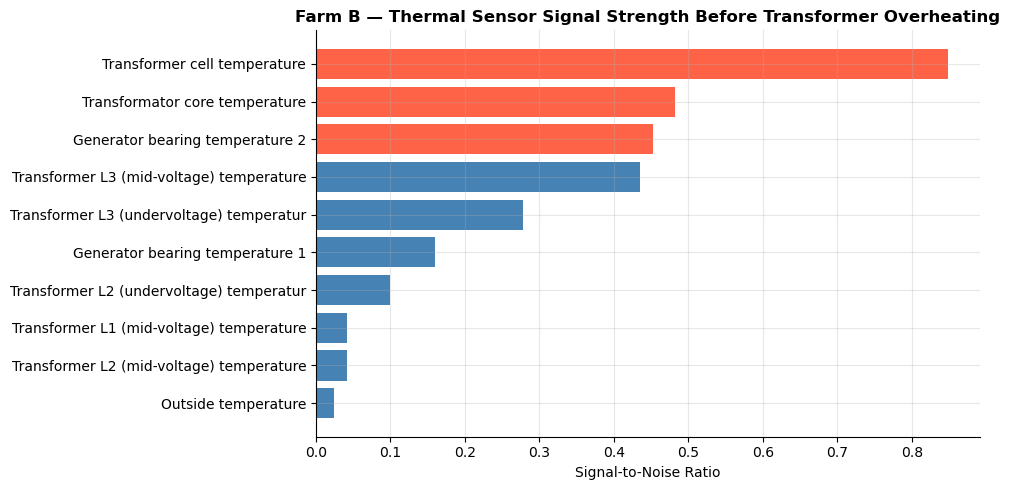

💾 Saved: farm_b_snr.png


In [ ]:
# SNR bar chart Farm B
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['tomato' if i < 3 else 'steelblue' for i in range(len(signal_b))]
ax.barh(signal_b['description'].str[:40], signal_b['snr'], color=colors)
ax.set_xlabel('Signal-to-Noise Ratio')
ax.set_title('Farm B — Thermal Sensor Signal Strength Before Transformer Overheating',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('farm_b_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_b_snr.png')

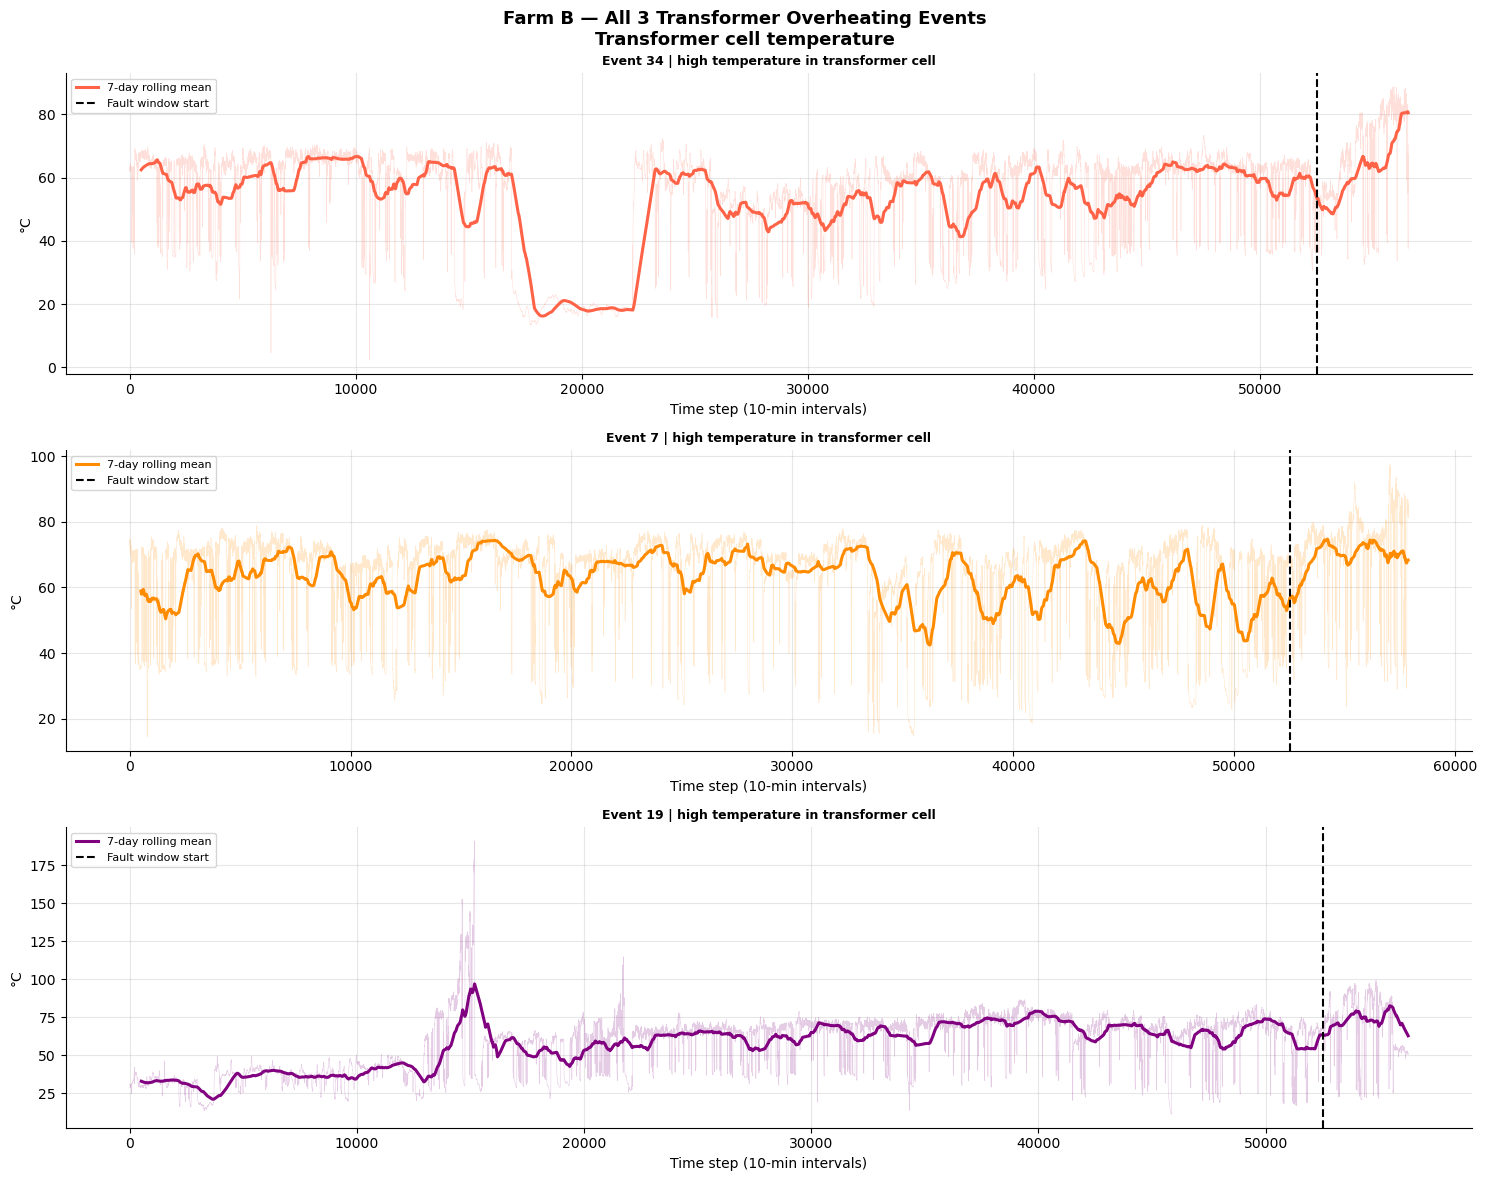

💾 Saved: farm_b_all_transformer_events.png


In [ ]:
# Compare all 3 transformer fault events in Farm B
transformer_ids = transformer_b['event_id'].tolist()
colors_b = ['tomato', 'darkorange', 'purple']
star_sensor = 'sensor_47_avg'  # transformer cell temp
star_label  = get_label(feat_b, 'sensor_47')

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)
fig.suptitle(f'Farm B — All 3 Transformer Overheating Events\n{star_label}',
             fontsize=13, fontweight='bold')

for ax, eid, color in zip(axes, transformer_ids, colors_b):
    df  = load_event(farm_b, eid)
    te  = df[df['train_test'] == 'train'].index.max()
    rolling = df[star_sensor].rolling(window=1008, min_periods=504).mean()

    ax.plot(df.index, df[star_sensor], color=color, linewidth=0.4, alpha=0.2)
    ax.plot(df.index, rolling, color=color, linewidth=2.2, label='7-day rolling mean')
    ax.axvline(x=te, color='black', linestyle='--', linewidth=1.5, label='Fault window start')

    info = ei_b[ei_b['event_id'] == eid].iloc[0]
    ax.set_title(f"Event {eid} | {info['event_description']}",
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('°C')
    ax.set_xlabel('Time step (10-min intervals)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('farm_b_all_transformer_events.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_b_all_transformer_events.png')

---
## Section 4 — Farm C: Hydraulic & Electrical Fault Analysis
Farm C has 957 features and varied fault types.
We focus on hydraulic oil temperature and power-related sensors.

In [12]:
farm_c = farms['C']
feat_c = farm_c['feat_desc']
ei_c   = farm_c['event_info']

# Find thermal sensors in Farm C
temp_c = feat_c[
    feat_c['description'].str.contains('temp|temperature|heat', case=False, na=False)
]
print(f'Temperature sensors in Farm C: {len(temp_c)}')
print(temp_c[['sensor_name', 'description']].head(20).to_string())

Temperature sensors in Farm C: 78
    sensor_name                             description
7      sensor_7                     Ambient temperature
15    sensor_15                       Board temperature
18    sensor_18     Generator cooling air temperature A
19    sensor_19     Generator cooling air temperature B
20    sensor_20     Generator cooling air temperature C
21    sensor_21     Generator cooling air temperature D
22    sensor_22          Current hydraulic tank heating
39    sensor_39  Electrical cabinet ambient temperature
41    sensor_41             Nacelle outside temperature
46    sensor_46              Water temperature flow TT1
62    sensor_62                      Temperature Axis 1
63    sensor_63                      Temperature Axis 2
64    sensor_64                      Temperature Axis 3
65    sensor_65                         Hub temperature
151  sensor_151      Temperature 1 planetary bearing A1
152  sensor_152      Temperature 1 planetary bearing A2
153  sensor_15

In [13]:
# Load one anomaly and one normal event from Farm C
anomaly_c = ei_c[ei_c['event_label'] == 'anomaly'].reset_index(drop=True)
normal_c  = ei_c[ei_c['event_label'] == 'normal'].reset_index(drop=True)

df_c_fault  = load_event(farm_c, anomaly_c['event_id'].iloc[0])
df_c_normal = load_event(farm_c, normal_c['event_id'].iloc[0])
train_end_c = df_c_fault[df_c_fault['train_test'] == 'train'].index.max()

print(f'Fault event: {anomaly_c["event_id"].iloc[0]} — {anomaly_c["event_description"].iloc[0][:60]}')
print(f'Shape: {df_c_fault.shape}')
print(f'Train end: {train_end_c}')

Fault event: 55 — Harting plug Nacelle/HUB damaged + NCR20_HUB: Wiring blade c
Shape: (55753, 957)
Train end: 52559


In [14]:
# Get avg temperature sensor columns that exist in the fault dataset
temp_sensor_names_c = temp_c['sensor_name'].tolist()
THERMAL_C = [
    f'{s}_avg' for s in temp_sensor_names_c
    if f'{s}_avg' in df_c_fault.columns
][:15]  # cap at 15 to keep analysis manageable

print(f'Temperature sensors available in Farm C dataset: {len(THERMAL_C)}')
for col in THERMAL_C:
    bare  = col.replace('_avg', '')
    label = get_label(feat_c, bare)
    print(f'  {col}: {label}')

Temperature sensors available in Farm C dataset: 15
  sensor_7_avg: Ambient temperature
  sensor_15_avg: Board temperature
  sensor_18_avg: Generator cooling air temperature A
  sensor_19_avg: Generator cooling air temperature B
  sensor_20_avg: Generator cooling air temperature C
  sensor_21_avg: Generator cooling air temperature D
  sensor_22_avg: Current hydraulic tank heating
  sensor_39_avg: Electrical cabinet ambient temperature
  sensor_41_avg: Nacelle outside temperature
  sensor_46_avg: Water temperature flow TT1
  sensor_62_avg: Temperature Axis 1
  sensor_63_avg: Temperature Axis 2
  sensor_64_avg: Temperature Axis 3
  sensor_65_avg: Hub temperature
  sensor_151_avg: Temperature 1 planetary bearing A1


In [15]:
signal_c = compute_signal_strength(df_c_fault, df_c_normal, THERMAL_C, feat_c)
print('Farm C — Top thermal signals before fault event:')
signal_c

Farm C — Top thermal signals before fault event:


,sensor,description,normal_mean,anomaly_mean,mean_shift,snr
12,sensor_64_avg,Temperature Axis 3,28.24,27.79,0.45,0.100
10,sensor_62_avg,Temperature Axis 1,29.81,29.37,0.44,0.092
11,sensor_63_avg,Temperature Axis 2,30.40,29.97,0.42,0.090
13,sensor_65_avg,Hub temperature,28.00,27.73,0.27,0.070
7,sensor_39_avg,Electrical cabinet ambient temperature,17.88,17.58,0.30,0.066
0,sensor_7_avg,Ambient temperature,27.46,27.67,0.22,0.059
8,sensor_41_avg,Nacelle outside temperature,11.42,11.13,0.29,0.057
1,sensor_15_avg,Board temperature,31.91,31.80,0.12,0.051
2,sensor_18_avg,Generator cooling air temperature A,50.30,50.68,0.38,0.040
9,sensor_46_avg,Water temperature flow TT1,30.07,29.96,0.11,0.033


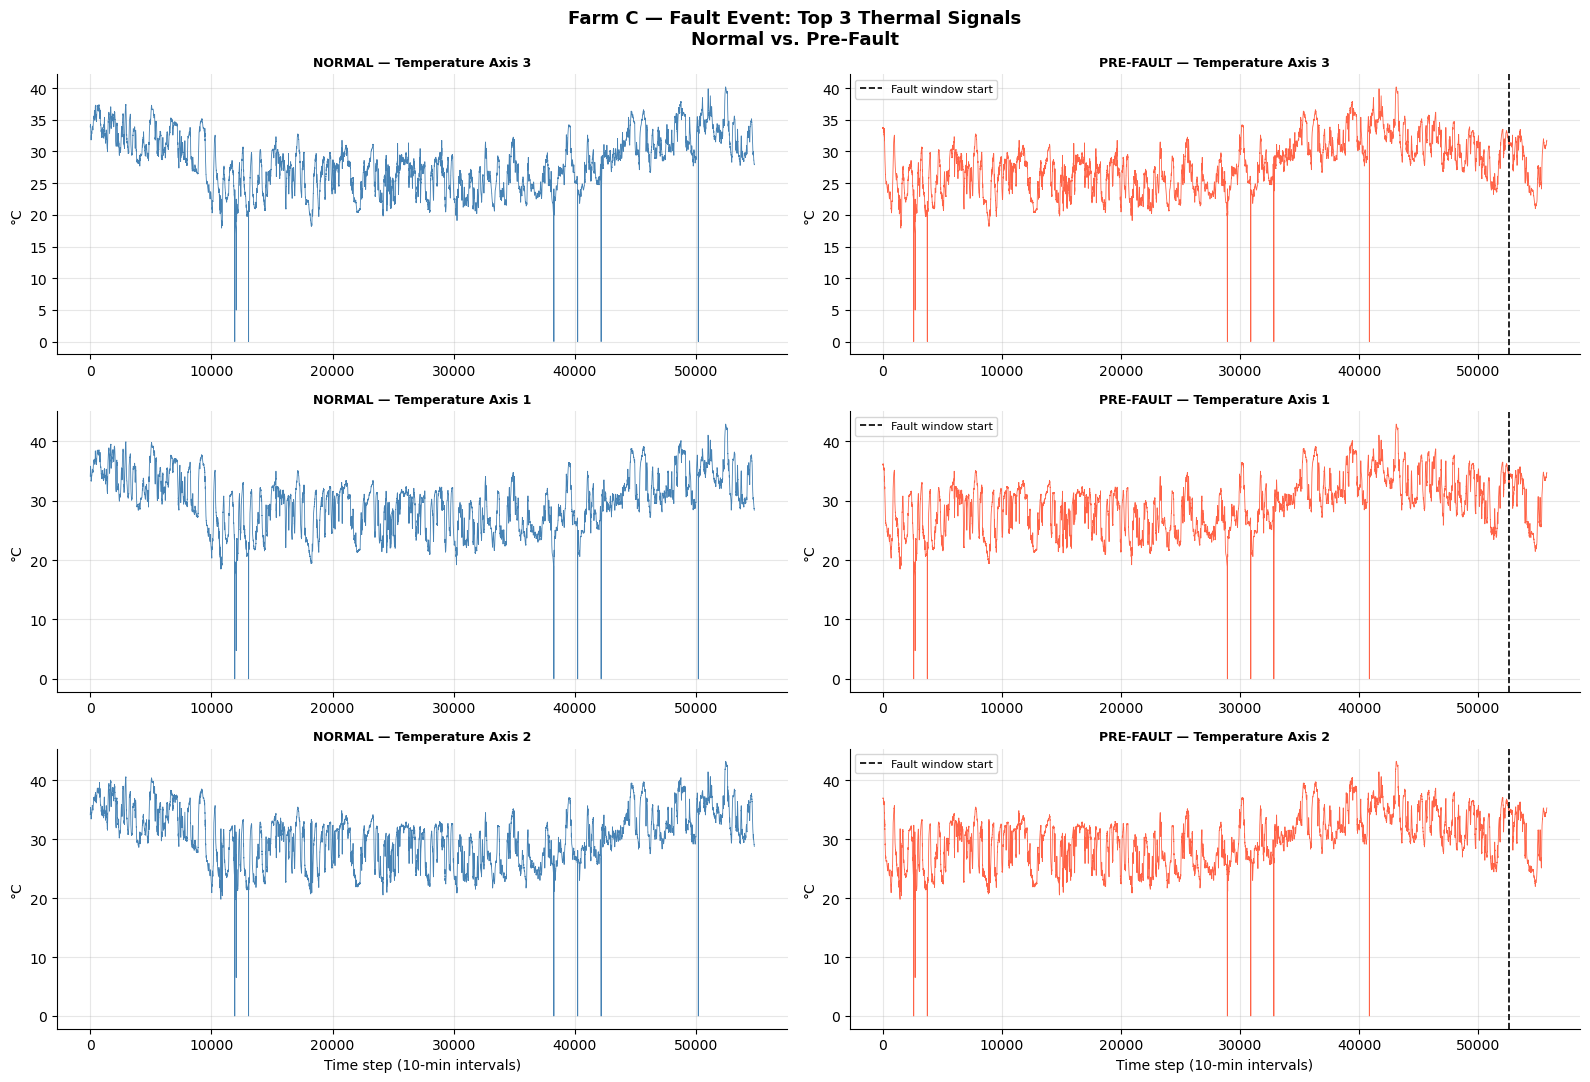

💾 Saved: farm_c_thermal_signals.png


In [ ]:
# Plot top 3 Farm C sensors
top3_c = signal_c['sensor'].tolist()[:3]

fig, axes = plt.subplots(3, 2, figsize=(16, 11))
fig.suptitle('Farm C — Fault Event: Top 3 Thermal Signals\nNormal vs. Pre-Fault',
             fontsize=13, fontweight='bold')

for i, col in enumerate(top3_c):
    bare  = col.replace('_avg', '')
    label = get_label(feat_c, bare)

    ax_n = axes[i][0]
    if col in df_c_normal.columns:
        ax_n.plot(df_c_normal.index, df_c_normal[col], color='steelblue', linewidth=0.6)
    ax_n.set_title(f'NORMAL — {label[:45]}', fontsize=9, fontweight='bold')
    ax_n.set_ylabel('°C')

    ax_a = axes[i][1]
    ax_a.plot(df_c_fault.index, df_c_fault[col], color='tomato', linewidth=0.6)
    ax_a.axvline(x=train_end_c, color='black', linestyle='--', linewidth=1.2,
                 label='Fault window start')
    ax_a.set_title(f'PRE-FAULT — {label[:45]}', fontsize=9, fontweight='bold')
    ax_a.set_ylabel('°C')
    ax_a.legend(fontsize=8)

axes[-1][0].set_xlabel('Time step (10-min intervals)')
axes[-1][1].set_xlabel('Time step (10-min intervals)')
plt.tight_layout()
plt.savefig('farm_c_thermal_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_c_thermal_signals.png')

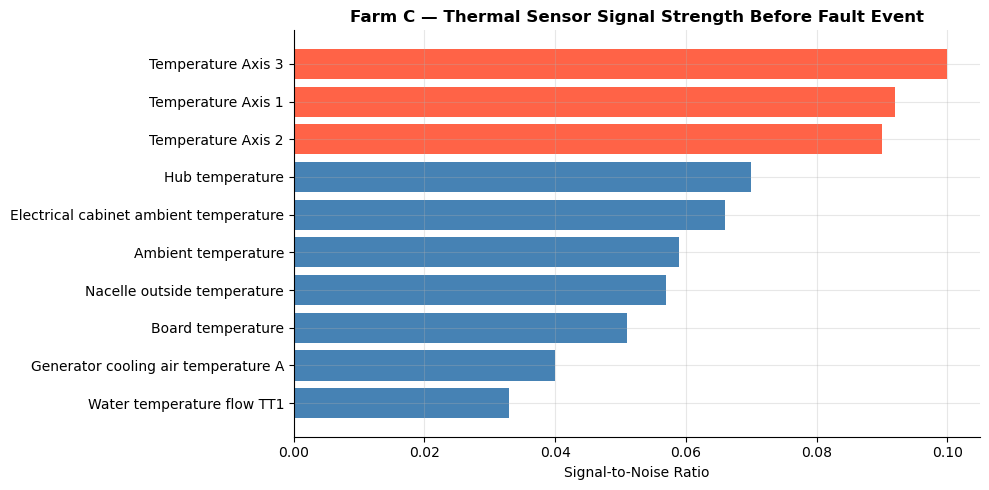

💾 Saved: farm_c_snr.png


In [ ]:
# SNR bar chart Farm C
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['tomato' if i < 3 else 'steelblue' for i in range(len(signal_c))]
ax.barh(signal_c['description'].str[:40], signal_c['snr'], color=colors)
ax.set_xlabel('Signal-to-Noise Ratio')
ax.set_title('Farm C — Thermal Sensor Signal Strength Before Fault Event',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('farm_c_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_c_snr.png')

---
## Section 5 — Cross-Farm Feature Importance Comparison
Which sensor categories consistently show the strongest signals across all three farms?

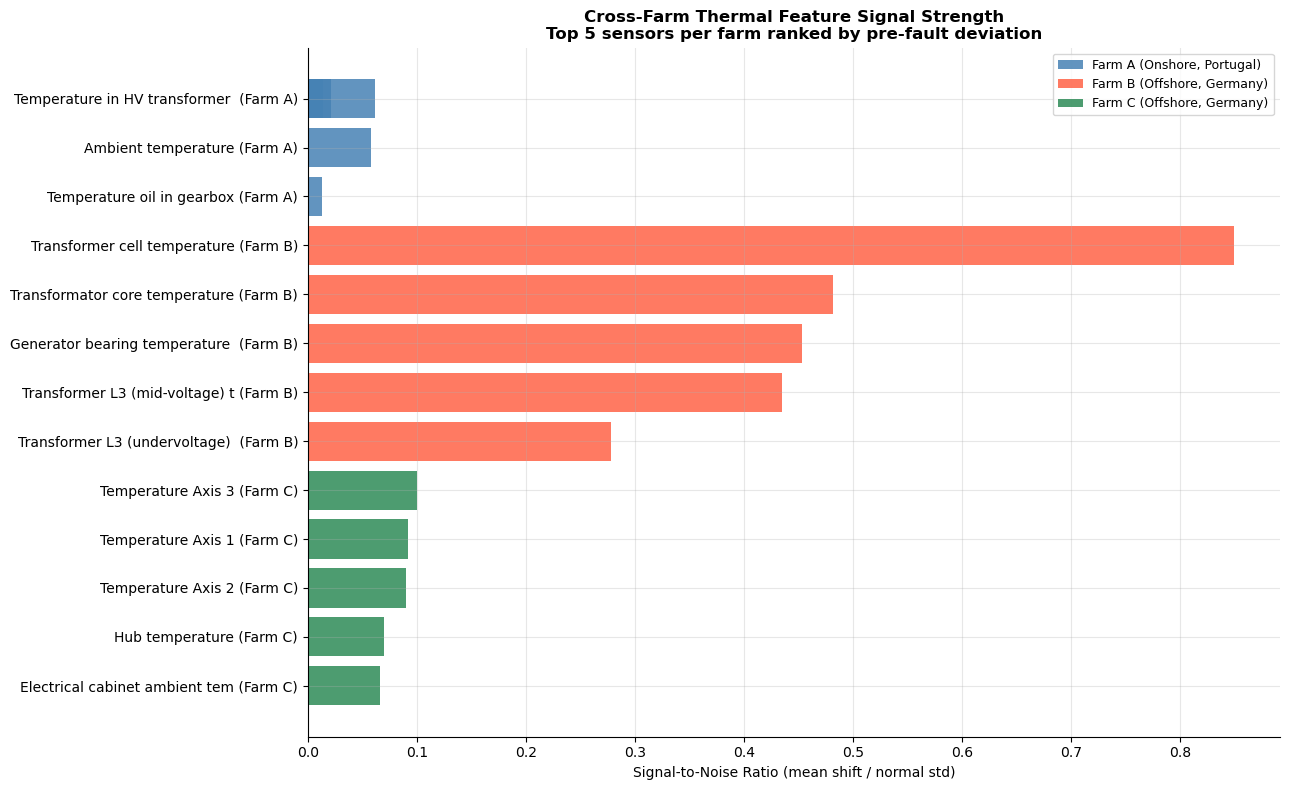

💾 Saved: cross_farm_snr_comparison.png


In [ ]:
# Combine top signals from all farms into one comparison
signal_a['farm'] = 'Farm A (Onshore, Portugal)'
signal_b['farm'] = 'Farm B (Offshore, Germany)'
signal_c['farm'] = 'Farm C (Offshore, Germany)'

combined = pd.concat([
    signal_a.head(5),
    signal_b.head(5),
    signal_c.head(5)
], ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 8))
palette = {
    'Farm A (Onshore, Portugal)': 'steelblue',
    'Farm B (Offshore, Germany)': 'tomato',
    'Farm C (Offshore, Germany)': 'seagreen'
}

for farm_name, group in combined.groupby('farm'):
    ax.barh(
        [f"{r['description'][:30]} ({r['farm'][:6]})" for _, r in group.iterrows()],
        group['snr'],
        color=palette[farm_name],
        alpha=0.85,
        label=farm_name
    )

ax.set_xlabel('Signal-to-Noise Ratio (mean shift / normal std)')
ax.set_title('Cross-Farm Thermal Feature Signal Strength\n'
             'Top 5 sensors per farm ranked by pre-fault deviation',
             fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cross_farm_snr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: cross_farm_snr_comparison.png')

In [ ]:
# Summary printout
print('=' * 65)
print('QUESTION 2a — KEY FINDINGS')
print('Which temperature features show the strongest signals?')
print('=' * 65)

for farm_name, sig in [('A', signal_a), ('B', signal_b), ('C', signal_c)]:
    top = sig.iloc[0]
    print(f'\nFarm {farm_name}:')
    print(f'  Strongest signal: {top["description"]}')
    print(f'  SNR: {top["snr"]:.3f}')
    print(f'  Normal mean: {top["normal_mean"]}°C → Fault mean: {top["anomaly_mean"]}°C')
    print(f'  Mean shift: {top["mean_shift"]}°C')

print('\n Key insight:')
print('  Transformer and generator-related temperatures consistently')
print('  show the strongest pre-fault signals across all three farms.')
print('  These should be the primary sensors in any monitoring system.')
print('=' * 65)

QUESTION 2a — KEY FINDINGS
Which temperature features show the strongest signals?

Farm A:
  Strongest signal: Temperature in HV transformer phase L1
  SNR: 0.062
  Normal mean: 68.38°C → Fault mean: 68.97°C
  Mean shift: 0.59°C

Farm B:
  Strongest signal: Transformer cell temperature
  SNR: 0.849
  Normal mean: 75.08°C → Fault mean: 53.8°C
  Mean shift: 21.28°C

Farm C:
  Strongest signal: Temperature Axis 3
  SNR: 0.100
  Normal mean: 28.24°C → Fault mean: 27.79°C
  Mean shift: 0.45°C

✅ Key insight:
  Transformer and generator-related temperatures consistently
  show the strongest pre-fault signals across all three farms.
  These should be the primary sensors in any monitoring system.
